<a href="https://colab.research.google.com/github/Toomito/trabajo-final-icd-2026/blob/main/TrabajoFinal_ICD_2026_V3(FINAL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final - Introducción a Ciencia de Datos 2026
**Alumnos:** Fransisco Leonori,Juanmanuel Rodon, Tomas Playa
**Dataset:** Default of Credit Card Clients (UCI / Kaggle)
**Objetivo:** Predecir incumplimiento de pago de tarjetas de crédito

### Librerías

Antes de empezar, importamos en un solo lugar todas las librerías que vamos a usar
a lo largo del trabajo. Las agrupamos acá por una cuestión de orden y para que sea
fácil ver de un vistazo qué herramientas utilizamos.

In [38]:
# ============================================
# LIBRERÍAS UTILIZADAS EN EL TRABAJO
# ============================================

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación de datos y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Configuración de estilo para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tomasplaya","key":"96d72fd7db40bfccb8d70ed95454bebd"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset
!unzip default-of-credit-card-clients-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
100% 0.98M/0.98M [00:00<00:00, 111MB/s]

Archive:  default-of-credit-card-clients-dataset.zip
  inflating: UCI_Credit_Card.csv     


In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('UCI_Credit_Card.csv')

print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


##Exploracion inicial del dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

#####Al realizar df.info() vemos que nuestro csv no cuenta con datos nullos y ademas vemos que cuenta con integer y floats (eteros y no enteros)                                                 Observamos que el nombre de default.payment.next.month es un poco incomodo para trabajar por el mismo asi que lo renombraremos a

In [7]:
df.rename(columns={'default.payment.next.month': 'PAYMENTNM'},inplace=True) #renombre de la columna
print("Columnas actualziadas con exito")
print(df.columns.tolist()) #imprime la lista de columasn

Columnas actualziadas con exito
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAYMENTNM']


###### La columna renombrada como PAYMENTNM nos otogra dice

0 si el cliente paga su tarjeta

1 si el cliente NO paga su tarjeta (incumplimeinto de pago)

La idea central es que nuestro modelo aprendera desde nuestro CSV para predecir el valor de PAYMENTNM

Para esto, analizaremos la distribucion de nuestra columan PAYMENTNM, viendo cuantos usuarios paga o no pagan sus tarjetas actualmente

In [8]:
print("Distribucion")
print(df['PAYMENTNM'].value_counts())
print("\nCalculo de procentaje:")
print(df['PAYMENTNM'].value_counts(normalize=True)* 100)

Distribucion
PAYMENTNM
0    23364
1     6636
Name: count, dtype: int64

Calculo de procentaje:
PAYMENTNM
0    77.88
1    22.12
Name: proportion, dtype: float64


###### Vemos que nuestro dataset no esta balanceado y eso afectara a el entremiento de nuestro modelo

Para ver esto de una mejor forma, presentamos el siguiente grafico


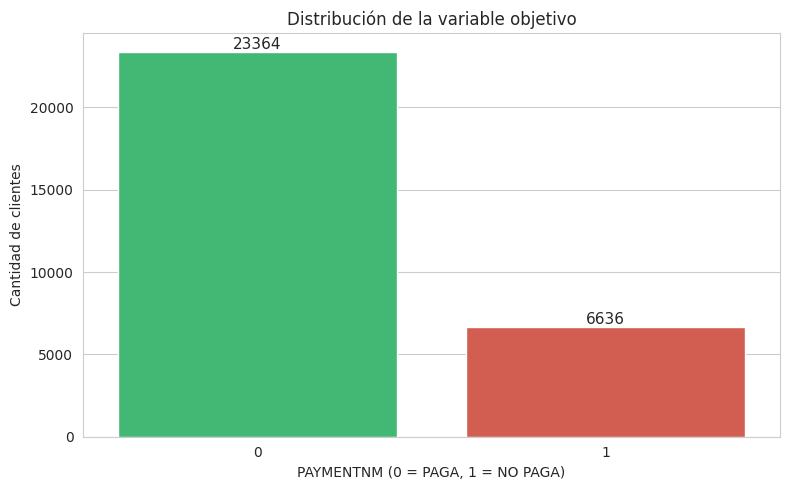

In [11]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='PAYMENTNM', data=df, hue='PAYMENTNM',
                   palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribución de la variable objetivo')
plt.xlabel('PAYMENTNM (0 = PAGA, 1 = NO PAGA)')
plt.ylabel('Cantidad de clientes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

### Observaciones sobre la distribución

El gráfico revela que el dataset está **fuertemente desbalanceado**:

- **23.364 clientes (77.88%)** cumplen con el pago de su tarjeta de crédito.
- **6.636 clientes (22.12%)** incumplen el pago del próximo mes.

Esto significa que por cada cliente que incumple, hay aproximadamente **3,5 clientes
que pagan**. El desbalance tiene dos consecuencias importantes para el análisis:

Como siguiente paso, procederemos a realizar una exploracion de las varibales mas importantes que suaremos para entendear a nuestro modelo

Realizaremos una exploracion en las variables SEX,EDUCATION,MARRIGE,AGE para ver que no tengamos informacion erronea o datos mal carados en nuestro CSV que luego nos pueden llevar a un mal entrenamiento del modelo


In [10]:
# Revision de valores

#VARIABLE CATEGORICA
print("SEX - valores únicos:", sorted(df['SEX'].unique()))
print("SEX - cantidad por valor:")
print(df['SEX'].value_counts().sort_index())
print()

#VARIABLE CATEGORICA
print("EDUCATION - valores únicos:", sorted(df['EDUCATION'].unique()))
print("EDUCATION - cantidad por valor:")
print(df['EDUCATION'].value_counts().sort_index())
print()

#VARIABLE CATEGORICA
print("MARRIAGE - valores únicos:", sorted(df['MARRIAGE'].unique()))
print("MARRIAGE - cantidad por valor:")
print(df['MARRIAGE'].value_counts().sort_index())
print()

#VARIABLE NUMERICA
print("AGE - estadísticas:")
print(f"  Mínimo:   {df['AGE'].min()} años")
print(f"  Máximo:   {df['AGE'].max()} años")
print(f"  Media:    {df['AGE'].mean():.2f} años")
print(f"  Mediana:  {df['AGE'].median()} años")
print(f"  Desvío:   {df['AGE'].std():.2f}")
print(f"  Cantidad de valores únicos: {df['AGE'].nunique()}")

SEX - valores únicos: [np.int64(1), np.int64(2)]
SEX - cantidad por valor:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION - valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
EDUCATION - cantidad por valor:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE - valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
MARRIAGE - cantidad por valor:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

AGE - estadísticas:
  Mínimo:   21 años
  Máximo:   79 años
  Media:    35.49 años
  Mediana:  34.0 años
  Desvío:   9.22
  Cantidad de valores únicos: 56


### Resumen del análisis de variables demográficas

A partir del análisis de las variables más importantes, podemos resumir lo siguiente:

#### 1. SEX (sexo)

Toma valores **1 y 2**:

- `1` = Hombre
- `2` = Mujer

Esta variable está limpia, no presenta valores inesperados.

#### 2. EDUCATION (nivel educativo)

Toma valores **del 0 al 6**:

- `1` = Graduado universitario
- `2` = Universidad
- `3` = Secundario
- `4` = Otros
- `0`, `5`, `6` = **No están documentados** ← problema a tratar en la limpieza

#### 3. MARRIAGE (estado civil)

Toma valores **del 0 al 3**:

- `1` = Casado
- `2` = Soltero
- `3` = Otros
- `0` = **No está documentado** ← problema a tratar en la limpieza

#### 4. AGE (edad)

Variable numérica continua:

- **Mínimo:** 21 años
- **Máximo:** 79 años
- **Media** 35.49 años
- **Mediana** 34.0 años

---





### Distribución de la edad de los clientes

La variable `AGE` es numérica continua, por lo que utilizamos un histograma para
visualizar su distribución. Esto nos permite identificar en qué rangos de edad
se concentra la mayoría de los clientes y detectar posibles sesgos en la muestra.

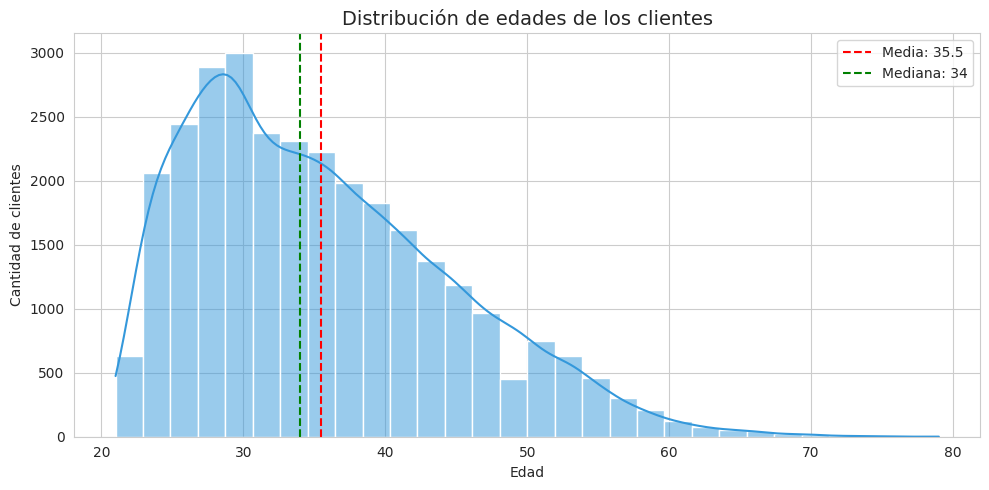

In [12]:
# Histograma de la distribución de edades
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='AGE', bins=30, kde=True, color='#3498db')
plt.title('Distribución de edades de los clientes', fontsize=14)
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.axvline(df['AGE'].mean(), color='red', linestyle='--',
            label=f'Media: {df["AGE"].mean():.1f}')
plt.axvline(df['AGE'].median(), color='green', linestyle='--',
            label=f'Mediana: {df["AGE"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

### Observaciones sobre la distribución de edades

El histograma muestra que la mayoría de los clientes son **adultos jóvenes**:

- La **mayor concentración** se da entre los **25 y 40 años**, con un pico cercano
  a los 28-30 años.
- La **edad media** es de **35,5 años** y la **mediana** de **34 años**.
- A partir de los 40 años la cantidad de clientes **disminuye progresivamente**,
  formando una cola hacia la derecha.

La distribución presenta un **sesgo positivo (asimetría a la derecha)**: la media
es mayor que la mediana porque el grupo reducido de clientes de mayor edad eleva
el promedio. Esto indica que la **mediana es un valor más representativo** del
cliente típico de este dataset.

Desde el punto de vista del negocio, esto tiene sentido: las tarjetas de crédito
son utilizadas mayormente por personas en edad económicamente activa.

### Acomodando las variables PAY

Ahora vamos a trabajar con las variables de historial de pagos. Lo primero que
notamos es algo raro: el dataset tiene las columnas `PAY_0`, `PAY_2`, `PAY_3`,
`PAY_4`, `PAY_5` y `PAY_6`, o sea que se saltea la `PAY_1`. No es que falte
información, las seis columnas están completas, simplemente el nombre quedó mal puesto.

Como el enunciado nos pide que en el análisis exploratorio acomodemos los datos,
decidimos renombrar `PAY_0` como `PAY_1`. De esta forma las columnas quedan numeradas
de manera ordenada y consistente (`PAY_1` a `PAY_6`), lo que hace más fácil
entenderlas y trabajarlas más adelante.

In [13]:
# Renombrar PAY_0 como PAY_1 para que las columnas queden ordenadas
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

# Verificar que el cambio se aplicó
print("Columnas de pago actuales:")
print([col for col in df.columns if col.startswith('PAY_') and 'AMT' not in col])

Columnas de pago actuales:
['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


### Ahora exploremos los datos que tenemos en las columnas PAY

In [14]:
# Revisar los valores que toman las variables de historial de pagos
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()

--- PAY_1 ---
PAY_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

--- PAY_2 ---
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

--- PAY_3 ---
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

--- PAY_4 ---
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

--- PAY_5 ---
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

--- PAY_6 ---
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 

### Qué significa cada valor de las columnas PAY

Antes de seguir, conviene aclarar qué representa cada número en las columnas
`PAY_1` a `PAY_6`, porque a primera vista son medio confusos (hay valores negativos,
ceros y positivos).

Según la documentación oficial del dataset, los valores serían así:

- `-1` → el cliente pagó al día, sin ningún atraso
- `1` → atraso de 1 mes en el pago
- `2` → atraso de 2 meses
- `3` → atraso de 3 meses
- y así sucesivamente hasta `8` o `9`, que serían atrasos de 8 o 9 meses o más

El problema es que cuando revisamos los datos nos encontramos con dos valores que
la documentación no explica: el `-2` y el `0`. Como aparecen bastante seguido y
no queríamos descartarlos sin más, buscamos cuál es la interpretación más aceptada
para este dataset y decidimos darles el siguiente sentido:

- `-2` → el cliente no tuvo consumo ese mes, es decir, no usó la tarjeta y por lo
  tanto no había nada que pagar
- `0` → el cliente sí usó la tarjeta y está pagando, pero arrastra saldo de un mes
  a otro (paga el mínimo o una parte) sin llegar a atrasarse formalmente

En resumen, el criterio que vamos a usar de acá en adelante es: los valores
negativos (`-2` y `-1`) representan situaciones donde el cliente está al día o
directamente no usó la tarjeta, el `0` es una situación intermedia de pago en
curso, y los valores positivos (`1` en adelante) indican meses de atraso, donde
cuanto más alto es el número, peor es la situación del cliente.

Vale aclarar que este tipo de ambigüedad es común en los datasets reales, donde
la documentación no siempre está completa, y parte del trabajo de análisis es
justamente interpretar los datos con criterio en lugar de descartarlos.

### Cómo se reparten los atrasos

Para visualizar el comportamiento de pago vamos a graficar la columna `PAY_1`,
que es la del mes más reciente. Elegimos esta porque, al ser la más cercana al
momento que queremos predecir, suele ser la que más información aporta sobre si
el cliente va a incumplir o no.

El gráfico nos muestra cuántos clientes hay en cada situación: los que no usaron
la tarjeta, los que están al día, los que tienen pagos en curso y los que arrastran
distintos meses de atraso.

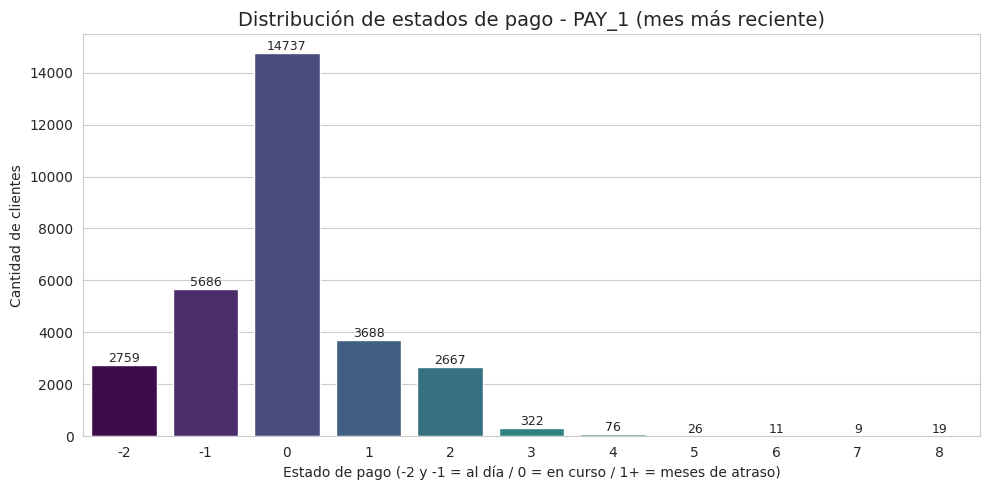

In [15]:
# Distribución de los estados de pago en el mes más reciente (PAY_1)
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='PAY_1', data=df, hue='PAY_1',
                   palette='viridis', legend=False)
plt.title('Distribución de estados de pago - PAY_1 (mes más reciente)', fontsize=14)
plt.xlabel('Estado de pago (-2 y -1 = al día / 0 = en curso / 1+ = meses de atraso)')
plt.ylabel('Cantidad de clientes')

# Agregar los números arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Qué nos dice este gráfico

Mirando la distribución se nota algo bastante claro: la enorme mayoría de los
clientes está en una situación de pago sana. La barra más alta de lejos es la
del valor 0 (pago en curso) con casi 15.000 clientes, y si le sumamos los valores
negativos (gente al día o que ni usó la tarjeta), llegamos a más o menos el 77%
del total.

Los atrasos reales, o sea los valores de 1 en adelante, son bastante menos
frecuentes. Y se ve un patrón muy marcado: cuanto más grande es el atraso, menos
clientes hay en esa situación. Pasamos de 3.688 clientes con 1 mes de atraso a
apenas un puñado con atrasos de 5, 6 o más meses.

Esto va totalmente de la mano con lo que ya habíamos visto al analizar la variable
objetivo. Tiene sentido: la mayoría de la gente paga, y el incumplimiento es la
minoría. Igual, ese grupo con atrasos va a ser clave más adelante, porque
seguramente es ahí donde se concentran la mayoría de los casos de incumplimiento.

### Gráfico de caja: límite de crédito según incumplimiento

Uno de los gráficos que nos pide el trabajo es un diagrama de caja y bigotes
(box plot). Lo vamos a usar para responder una pregunta concreta: ¿el monto de
crédito que el banco le otorga a un cliente tiene algo que ver con que después
pague o no?

La idea es comparar la variable `LIMIT_BAL` (el límite de crédito otorgado) entre
los dos grupos: los que pagaron (0) y los que incumplieron (1). Si las cajas se
ven distintas, quiere decir que esta variable nos sirve para predecir. Si se ven
parecidas, no aporta tanto.

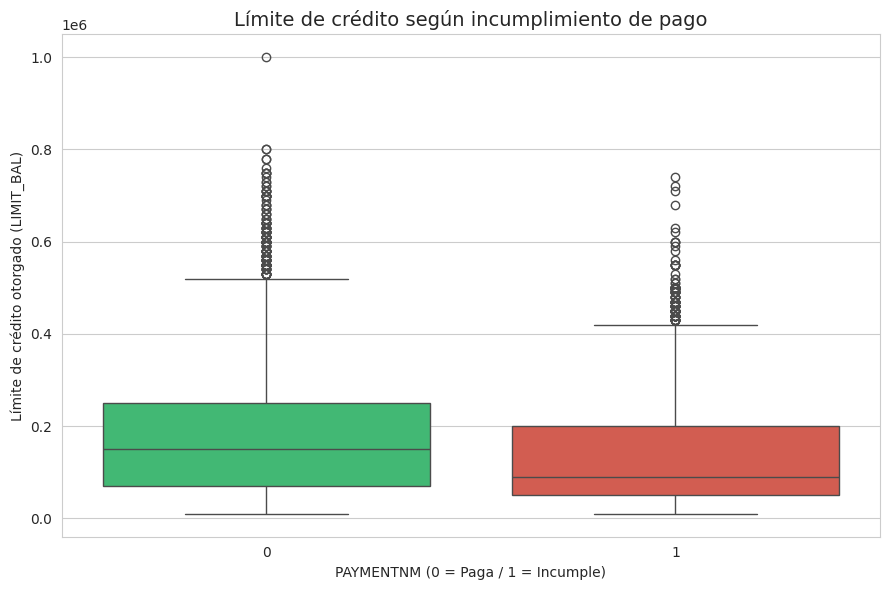

In [16]:
# Box plot: LIMIT_BAL comparado entre quienes pagan y quienes incumplen
plt.figure(figsize=(9, 6))
sns.boxplot(x='PAYMENTNM', y='LIMIT_BAL', data=df,
            hue='PAYMENTNM', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Límite de crédito según incumplimiento de pago', fontsize=14)
plt.xlabel('PAYMENTNM (0 = Paga / 1 = Incumple)')
plt.ylabel('Límite de crédito otorgado (LIMIT_BAL)')
plt.tight_layout()
plt.show()

### Qué nos dice este gráfico

Acá ya empezamos a ver algo interesante. Si comparamos las dos cajas, se nota
bastante claro que los clientes que terminan incumpliendo tienden a tener un
límite de crédito más bajo que los que pagan.

La mediana del grupo que paga (la caja verde) está cerca de los 150.000, mientras
que la del grupo que incumple (la caja roja) ronda los 90.000. Y no es solo la
mediana: toda la caja roja está corrida hacia abajo, lo que significa que en
general este grupo maneja límites de crédito menores.

Esto tiene una explicación lógica desde el lado del banco. El límite de crédito
no se asigna al azar: a los clientes que el banco considera más confiables les
otorga montos más altos. Entonces no sorprende que los clientes con créditos más
chicos, que en principio son perfiles de mayor riesgo, sean los que más incumplen.

También se ven muchos puntitos sueltos arriba de los bigotes. Esos son los outliers,
o sea clientes con límites de crédito muy por encima del resto. Se notan sobre todo
en el grupo que paga, donde aparecen créditos que llegan hasta el millón.

La conclusión es que `LIMIT_BAL` sí nos sirve como variable predictora: hay una
diferencia real entre los dos grupos, aunque las cajas igual se solapan bastante,
así que por sí sola no alcanza para predecir, va a tener que combinarse con las demás.

### Gráfico de violín: edad según incumplimiento

La diferencia con el box plot es que, además de mostrarnos los cuartiles y la mediana, nos deja ver la forma
completa de la distribución: dónde se concentra la mayor cantidad de gente y dónde
hay menos. Donde el violín es más ancho, hay más clientes en esa zona.

Lo vamos a usar para comparar la edad entre los que pagan y los que incumplen, y
así ver si hay alguna franja etaria donde el incumplimiento sea más común.

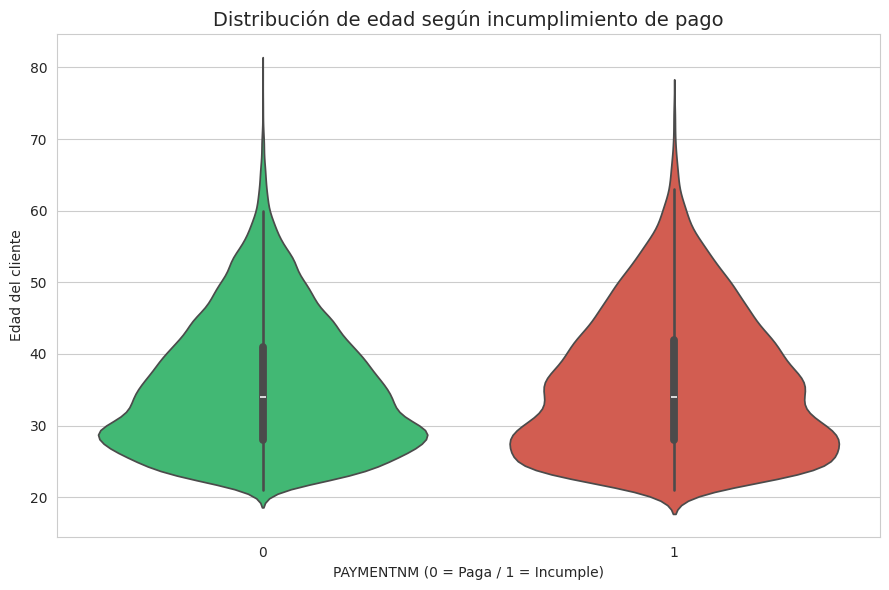

In [17]:
# Violin plot: AGE comparado entre quienes pagan y quienes incumplen
plt.figure(figsize=(9, 6))
sns.violinplot(x='PAYMENTNM', y='AGE', data=df,
               hue='PAYMENTNM', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribución de edad según incumplimiento de pago', fontsize=14)
plt.xlabel('PAYMENTNM (0 = Paga / 1 = Incumple)')
plt.ylabel('Edad del cliente')
plt.tight_layout()
plt.show()

### Qué nos dice este gráfico

Acá pasa algo distinto a lo que vimos con el límite de crédito. Si miramos los dos
violines, son prácticamente iguales: tienen casi la misma forma, están abultados
en la misma zona (la de los adultos jóvenes, entre los 25 y 40 años) y sus medianas
están casi pegadas, las dos alrededor de los 34 años.

En otras palabras, la edad no parece marcar una diferencia real entre los clientes
que pagan y los que incumplen. Si tomamos a una persona al azar, su edad no nos da
mucha pista sobre si va a pagar o no.

Lo único que se nota, y de forma bastante sutil, es que el violín del grupo que
incumple está un poquito más ancho en la franja de los 25 a 30 años. Esto podría
sugerir que entre los más jóvenes hay una proporción levemente mayor de
incumplimiento, quizás por tener menos experiencia manejando crédito, pero es una
diferencia tan chica que no podemos sacar una conclusión fuerte de ahí.

La comparación con el gráfico anterior es interesante. Mientras que `LIMIT_BAL`
sí mostraba una diferencia clara entre los dos grupos, `AGE` se comporta como una
variable mucho menos informativa. Esto nos deja una primera pista de cara a la
selección de características: no todas las variables van a aportarle lo mismo al
modelo, y la edad probablemente sea de las que menos peso tenga.

### Mapa de calor: correlaciones entre todas las variables

Para cerrar el análisis exploratorio vamos a hacer un mapa de calor. La idea es
ver de un solo vistazo cómo se relacionan todas las variables entre sí, usando la
correlación de Pearson.

La correlación es un número entre -1 y 1 que nos dice qué tan relacionadas están
dos variables: si es cercana a 1, cuando una sube la otra también sube; si es
cercana a -1, cuando una sube la otra baja; y si es cercana a 0, no hay relación
entre ellas. En el gráfico, los colores nos ayudan a verlo más rápido que mirando
puros números.

Esto nos sirve para dos cosas: detectar variables que estén muy relacionadas entre
sí (información repetida) y, sobre todo, ver cuáles son las que más se relacionan
con nuestra variable objetivo, o sea las que más nos van a servir para predecir.

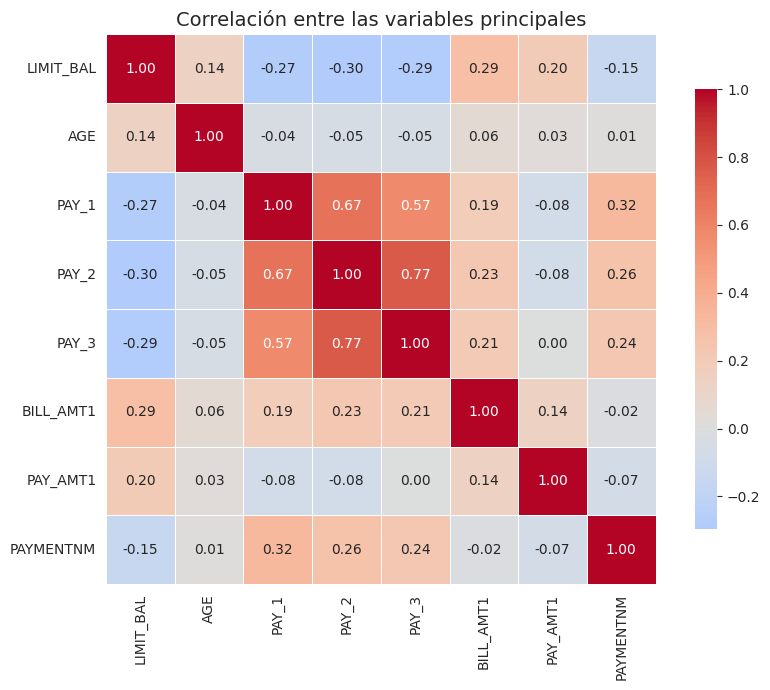

In [18]:
# Heatmap enfocado: solo las variables más relevantes para el problema
variables_clave = ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3',
                    'BILL_AMT1', 'PAY_AMT1', 'PAYMENTNM']

plt.figure(figsize=(9, 7))
sns.heatmap(df[variables_clave].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            annot_kws={'size': 10}, cbar_kws={'shrink': 0.8})
plt.title('Correlación entre las variables principales', fontsize=14)
plt.tight_layout()
plt.show()

### Cómo se relacionan las variables principales entre sí

En esta gráfica miramos un grupo reducido de variables, pero esta vez no
solo contra el objetivo, sino entre ellas. Esto nos sirve para detectar si hay
variables que estén dando información repetida.

Y acá aparece algo interesante. Si miramos las variables de pago (`PAY_1`, `PAY_2`,
`PAY_3`), están bastante correlacionadas entre sí, lo cual es lógico: un cliente
que se atrasa un mes suele venir arrastrando atrasos de los meses anteriores.

Algo parecido pasa, y de forma todavía más marcada, con los montos facturados
(`BILL_AMT`). En el mapa completo se veía que las seis columnas `BILL_AMT` forman
un bloque súper relacionado entre sí, con correlaciones altísimas. Esto pasa porque
el saldo de un mes depende mucho del mes anterior, así que esas variables aportan
prácticamente lo mismo.

Esto es importante de cara al siguiente paso del trabajo. Tener variables que dicen
casi lo mismo es redundante, y es algo que vamos a tener en cuenta cuando hagamos
la selección de características antes de entrenar los modelos.

En resumen, el mapa de calor nos deja dos conclusiones claras: el historial de
pagos reciente es lo que más pesa para predecir el incumplimiento, y hay grupos
de variables que están tan relacionadas entre sí que no hace falta usarlas todas.

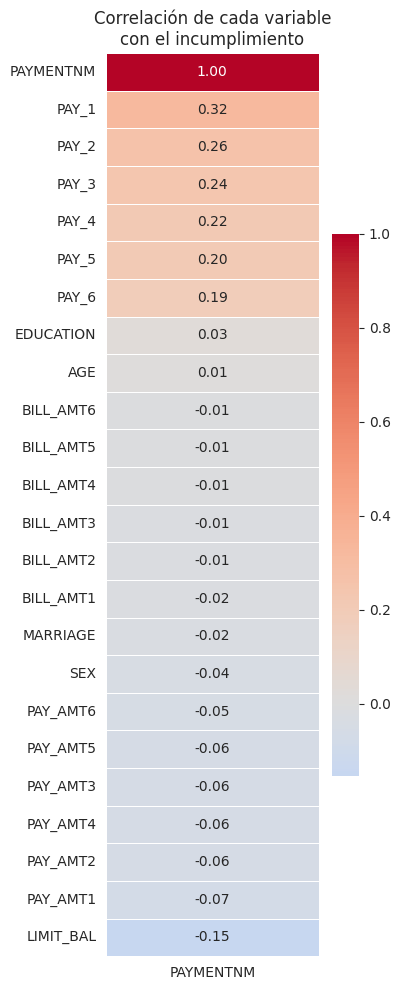

In [19]:
# Heatmap de la correlación de cada variable con la variable objetivo
corr_objetivo = df.drop(columns=['ID']).corr()[['PAYMENTNM']].sort_values(
    by='PAYMENTNM', ascending=False)

plt.figure(figsize=(4, 10))
sns.heatmap(corr_objetivo, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 10},
            cbar_kws={'shrink': 0.6})
plt.title('Correlación de cada variable\ncon el incumplimiento', fontsize=12)
plt.tight_layout()
plt.show()

### Mapa de calor: qué variables nos sirven para predecir

Para cerrar el análisis exploratorio y justificar el criterio que utilizamos para elejir las variables del grafico anterior usamos como idea medir
la correlación entre las variables, que es un número entre -1 y 1 que nos dice
qué tan relacionadas están. Si está cerca de 1, las dos suben juntas; si está
cerca de -1, cuando una sube la otra baja; y si está cerca de 0, no tienen relación.

Nos enfocamos en lo más importante: cuánto se relaciona
cada variable con nuestro objetivo, el incumplimiento (`PAYMENTNM`). Está ordenada
de mayor a menor, así que se lee como un ranking de qué tan útil es cada variable
para predecir.

Lo que vemos confirma con números lo que veníamos sospechando:

- Las variables del historial de pagos (`PAY_1` a `PAY_6`) son por lejos las más
  relacionadas con el incumplimiento. La más fuerte es `PAY_1`, el mes más reciente.
  Tiene todo el sentido: si una persona viene atrasándose en los pagos, lo más
  probable es que siga incumpliendo. El pasado reciente es el mejor predictor del
  futuro inmediato.

- `LIMIT_BAL` aparece con una correlación negativa. O sea, cuanto más alto el
  límite de crédito, menor la chance de incumplir. Esto confirma lo que ya habíamos
  visto en el gráfico de caja.

- `AGE` tiene una correlación casi nula, lo que también confirma lo del gráfico de
  violín: la edad no nos ayuda mucho a la hora de predecir.

### Resumen de lo que encontramos en el análisis exploratorio

Antes de pasar a la siguiente etapa, vale la pena frenar un segundo y juntar todo
lo que vimos hasta acá:

- El dataset tiene 30.000 clientes y no presenta valores nulos ni filas duplicadas,
  así que en ese sentido está bastante limpio.

- La variable objetivo está desbalanceada: alrededor del 78% de los clientes paga
  y solo el 22% incumple. Esto lo vamos a tener muy presente más adelante, porque
  significa que no nos podemos guiar solo por el porcentaje de aciertos para evaluar
  los modelos.

- Encontramos algunos valores que no estaban documentados: los valores 0, 5 y 6 en
  `EDUCATION` y el 0 en `MARRIAGE`. También vimos los valores -2 y 0 en las columnas
  de pago, a los que les dimos una interpretación con criterio.

- El historial de pagos reciente es lo que más se relaciona con el incumplimiento.
  La variable `PAY_1` (el último mes) es la más predictiva de todas.

- El límite de crédito (`LIMIT_BAL`) también aporta: los clientes que incumplen
  suelen tener límites más bajos.

- En cambio, la edad (`AGE`) resultó ser una variable poco útil para predecir, ya
  que se comporta casi igual entre los que pagan y los que no.

- Detectamos que varias variables están muy relacionadas entre sí, sobre todo los
  montos facturados (`BILL_AMT`), lo que nos dice que hay información repetida.

Con todo esto en claro, ya estamos listos para pasar a la siguiente fase, donde
vamos a limpiar y preparar los datos para poder entrenar los modelos.

---

# FASE 2: Entrenamiento del Modelo

En esta fase vamos a preparar los datos para que un modelo de Machine Learning pueda
aprender de ellos. Esto incluye acomodar los valores raros que detectamos en el
análisis, transformar las variables categóricas, escalar las numéricas y separar
los datos en un conjunto de entrenamiento y otro de prueba. Una vez listo todo eso,
vamos a entrenar dos modelos: Regresión Logística y Random Forest.

---

### Limpieza de los datos

Antes de entrenar cualquier modelo, vamos a acomodar algunas cosas que detectamos
durante el análisis exploratorio.

Lo primero son los valores no documentados. En la variable `EDUCATION` aparecían
los valores 0, 5 y 6, que la documentación oficial no explica. Como ya existe una
categoría 4 que significa "otros", decidimos mandar esos tres valores ahí. La lógica
es simple: si no sabemos qué nivel educativo representan, lo más razonable es
tratarlos como casos no clasificables, que es justo lo que significa "otros". Lo
mismo hacemos con el valor 0 de `MARRIAGE`, que va a parar a la categoría 3 ("otros").

Elegimos agrupar y no borrar estas filas porque son clientes válidos y no tiene
sentido perder datos pudiendo aprovecharlos.

Lo segundo es la columna `ID`. Esta columna es solo un número que identifica a
cada cliente y no dice nada sobre su comportamiento de pago, así que la vamos a
eliminar para que no le meta ruido al modelo.

Hay otras cosas que decidimos NO tocar a propósito: los valores -2 y 0 de las
columnas de pago (que ya interpretamos antes y representan situaciones reales) y
los valores negativos de los montos facturados (que simplemente indican que el
cliente pagó de más). No son errores, son datos válidos, y borrarlos sería perder
información útil.

In [20]:
# 1. Agrupar valores no documentados de EDUCATION en la categoría "otros" (4)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# 2. Agrupar el valor no documentado de MARRIAGE en la categoría "otros" (3)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

# 3. Eliminar la columna ID, que no aporta información al modelo
df = df.drop(columns=['ID'])

print("Limpieza aplicada correctamente.")

Limpieza aplicada correctamente.


In [21]:
# Verificar que la limpieza se aplicó correctamente

print("=== EDUCATION ===")
print("Valores únicos ahora:", sorted(df['EDUCATION'].unique()))
print(df['EDUCATION'].value_counts().sort_index())
print()

print("=== MARRIAGE ===")
print("Valores únicos ahora:", sorted(df['MARRIAGE'].unique()))
print(df['MARRIAGE'].value_counts().sort_index())
print()

print("=== Columna ID ===")
print("ID sigue en el dataset:", 'ID' in df.columns)
print("Dimensiones del dataset:", df.shape)

=== EDUCATION ===
Valores únicos ahora: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE ===
Valores únicos ahora: [np.int64(1), np.int64(2), np.int64(3)]
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

=== Columna ID ===
ID sigue en el dataset: False
Dimensiones del dataset: (30000, 24)


### Por qué verificamos

Cada vez que modificamos los datos, conviene frenar y comprobar que el cambio se
aplicó como esperábamos. No alcanza con escribir el código y confiar en que funcionó:
un error chico, como una variable mal escrita o un valor que se nos pasó, puede
arrastrarse hasta el final del trabajo y arruinar todo el análisis sin que nos
demos cuenta.

Por eso, después de la limpieza volvimos a mirar los valores únicos de `EDUCATION`
y `MARRIAGE`, y confirmamos que la columna `ID` ya no está. Como se ve en la salida
anterior, `EDUCATION` ahora solo tiene los valores del 1 al 4, `MARRIAGE` solo del
1 al 3, y el dataset pasó de 25 a 24 columnas. Todo quedó como queríamos.

Verificar también nos da tranquilidad para seguir avanzando, porque sabemos que
estamos construyendo sobre una base sólida.

### One-hot encoding

El one-hot encoding es una técnica que convierte las variables categóricas en
varias columnas de 0 y 1, una por cada categoría. Lo usamos porque, aunque variables
como `SEX`, `EDUCATION` y `MARRIAGE` ya son números, el modelo las interpretaría
como si tuvieran un orden que en realidad no existe. Con esta técnica, el modelo
las entiende como lo que son: categorías independientes, sin un orden falso entre ellas.

In [22]:
# One-hot encoding de las variables categóricas
# drop_first=True elimina una columna por variable para evitar redundancia
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# Ver cómo quedó el dataset
print("Dimensiones después del encoding:", df.shape)
print("\nColumnas actuales:")
print(df.columns.tolist())

Dimensiones después del encoding: (30000, 27)

Columnas actuales:
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAYMENTNM', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']


### Por qué separamos las variables

Una vez listas las transformaciones, dividimos el dataset en dos partes.

Por un lado armamos la X, que contiene todas las variables predictoras, es decir,
toda la información que describe a cada cliente: su límite de crédito, su edad, su
historial de pagos, etc. Por otro lado armamos la y, que es únicamente la variable
objetivo `PAYMENTNM`, lo que queremos predecir.

Hacemos esta separación porque un modelo de Machine Learning supervisado aprende
buscando la relación entre dos cosas: las características de cada cliente (X) y el
resultado que ya conocemos, si pagó o no (y). Necesitamos tenerlas separadas para
poder decirle al modelo "estudiá estas características y aprendé a predecir este
resultado". Si estuvieran todas mezcladas en una sola tabla, el modelo no sabría
qué tiene que predecir y qué tiene que usar para predecir.

In [23]:
# Separar las variables predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['PAYMENTNM'])
y = df['PAYMENTNM']

print("Dimensiones de X (predictoras):", X.shape)
print("Dimensiones de y (objetivo):", y.shape)

Dimensiones de X (predictoras): (30000, 26)
Dimensiones de y (objetivo): (30000,)


### Dividiendo en entrenamiento y prueba

Antes de entrenar, dividimos los datos en dos grupos. Uno de entrenamiento, con el
80% de los clientes, que es con el que el modelo va a aprender. Y otro de prueba,
con el 20% restante, que el modelo no va a ver durante el entrenamiento y que vamos
a usar después para evaluarlo.

La idea detrás de esto es parecida a estudiar para un examen. Si el modelo aprende
y después lo evaluamos con los mismos datos, va a parecer perfecto, pero solo porque
"memorizó" las respuestas. Para saber si realmente aprendió, tenemos que ponerlo a
prueba con casos nuevos que nunca vio.

Acá es donde nos sirve algo que detectamos al principio del trabajo: que el dataset
estaba desbalanceado, con un 78% de clientes que pagan y solo un 22% que incumplen.
Si dividiéramos los datos al azar sin tener esto en cuenta, podría pasar que uno de
los grupos quede con muchos más incumplidores que el otro, lo que dejaría la
evaluación poco confiable. Para evitarlo usamos la función train_test_split de
sklearn.model_selection con la opción stratify, que se encarga de mantener esa
proporción de 78/22 igual en los dos grupos. Y con random_state fijamos la división
para que siempre sea la misma, así cualquiera que corra el trabajo obtiene los
mismos resultados. la misma, así
cualquiera que corra el trabajo obtiene los mismos resultados.

In [24]:
# Dividir en entrenamiento (80%) y prueba (20%)
# stratify=y mantiene la proporción de la variable objetivo en ambos conjuntos
# random_state=42 hace que la división sea siempre la misma (resultados reproducibles)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Entrenamiento:", X_train.shape[0], "clientes")
print("Prueba:", X_test.shape[0], "clientes")
print()
print("Proporción de incumplimiento en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Proporción de incumplimiento en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Entrenamiento: 24000 clientes
Prueba: 6000 clientes

Proporción de incumplimiento en entrenamiento:
PAYMENTNM
0    0.779
1    0.221
Name: proportion, dtype: float64

Proporción de incumplimiento en prueba:
PAYMENTNM
0    0.779
1    0.221
Name: proportion, dtype: float64


### Escalando las variables

Nuestras variables numéricas están en escalas muy distintas. Por ejemplo, la edad
va de 21 a 79, mientras que el límite de crédito puede llegar al millón. Esto es
un problema para la Regresión Logística, porque tiende a darle más importancia a
las variables con números más grandes solo por su tamaño, y no porque realmente
sean más relevantes.

Para emparejar la cancha usamos el escalado, que pone todas las variables en una
escala comparable. Aplicamos StandardScaler, que transforma cada variable para que
tenga media 0 y un desvío parecido.

Hay un detalle importante en cómo lo hacemos. El escalador aprende sus parámetros
únicamente del conjunto de entrenamiento, y después esos mismos parámetros se
aplican al conjunto de prueba. Esto es así para que el modelo no tenga ningún tipo
de información del conjunto de prueba antes de tiempo. Si dejáramos que el escalador
también mirara los datos de prueba, sería como dejar que el modelo espíe el examen,
y los resultados que obtendríamos serían mejores de lo que realmente son.

In [25]:
# Crear el escalador
scaler = StandardScaler()

# El escalador APRENDE los parámetros solo del conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Al conjunto de prueba solo le APLICAMOS la transformación ya aprendida
X_test_scaled = scaler.transform(X_test)

print("Escalado aplicado correctamente.")
print("Dimensiones de X_train escalado:", X_train_scaled.shape)
print("Dimensiones de X_test escalado:", X_test_scaled.shape)

Escalado aplicado correctamente.
Dimensiones de X_train escalado: (24000, 26)
Dimensiones de X_test escalado: (6000, 26)


In [26]:
print("X_train_scaled existe:", 'X_train_scaled' in dir())
print("y_train existe:", 'y_train' in dir())

X_train_scaled existe: True
y_train existe: True


### Modelo 1: Regresión Logística

El primer modelo que vamos a entrenar es la Regresión Logística. A pesar de su
nombre, es un modelo de clasificación: lo que hace es estimar la probabilidad de
que un cliente incumpla el pago. Si esa probabilidad es alta, lo clasifica como
incumplidor, y si es baja, como pagador.

Es un modelo simple y rápido, lo que lo hace ideal como punto de partida para
después compararlo con uno más complejo.

Acá volvemos a usar lo que sabíamos del desbalance del dataset. Como la mayoría de
los clientes paga, un modelo entrenado sin ningún ajuste tendería a predecir
"paga" casi siempre, y se equivocaría justo con los incumplidores, que son los
que más nos interesa detectar. Para corregir esto usamos la opción
class_weight='balanced', que le indica al modelo que les dé más importancia a los
casos de la clase minoritaria, equilibrando la balanza.

In [27]:
# Crear y entrenar el modelo de Regresión Logística
# class_weight='balanced' compensa el desbalance del dataset
modelo_rl = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_rl.fit(X_train_scaled, y_train)

# Predecir sobre el conjunto de prueba
y_pred_rl = modelo_rl.predict(X_test_scaled)

print("Modelo de Regresión Logística entrenado correctamente.")
print("Predicciones generadas sobre el conjunto de prueba.")

Modelo de Regresión Logística entrenado correctamente.
Predicciones generadas sobre el conjunto de prueba.


### Modelo 2: Random Forest

El segundo modelo que vamos a entrenar es el Random Forest, que es bastante más
complejo que el anterior. Su idea es interesante: en lugar de tomar una decisión
con un solo criterio, construye muchos árboles de decisión, cada uno como un
cuestionario de preguntas encadenadas sobre las características del cliente.

El "bosque" arma cientos de estos árboles, cada uno mirando los datos de una forma
un poco distinta, y la predicción final se decide por una especie de votación entre
todos. La lógica es que muchas opiniones diferentes combinadas suelen acertar más
que una sola.

Elegimos este modelo justamente para contrastarlo con la Regresión Logística.
Mientras que aquel es un modelo simple y lineal, el Random Forest puede capturar
relaciones más complejas entre las variables. Comparar uno simple contra uno más
elaborado nos va a permitir ver cuál se adapta mejor a nuestro problema.

Al igual que en el modelo anterior, usamos class_weight='balanced' para compensar
el desbalance del dataset y que el modelo no ignore a los clientes que incumplen.

In [30]:
# Crear y entrenar el modelo de Random Forest
# n_estimators=100 indica que el bosque tendrá 100 árboles
# class_weight='balanced' compensa el desbalance del dataset
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

# Predecir sobre el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test_scaled)

print("Modelo de Random Forest entrenado correctamente.")
print("Predicciones generadas sobre el conjunto de prueba.")

Modelo de Random Forest entrenado correctamente.
Predicciones generadas sobre el conjunto de prueba.


---

# FASE 3: Evaluación del Modelo

Ya con los dos modelos entrenados, llega el momento de evaluarlos. En esta fase
vamos a medir qué tan bien funciona cada uno usando el conjunto de prueba, esos
datos que los modelos nunca vieron durante el entrenamiento. Analizaremos distintas
métricas, graficaremos la matriz de confusión de cada modelo y finalmente los
compararemos para decidir cuál se adapta mejor a nuestro problema.

---

### Evaluación del Modelo 1: Regresión Logística

Vamos a medir el rendimiento de la Regresión Logística sobre el conjunto de prueba.
Usamos un reporte que nos muestra las métricas principales: accuracy, precision,
recall y F1-score. Como nuestro dataset está desbalanceado, no nos vamos a quedar
solo con el accuracy, sino que vamos a mirar especialmente el recall de la clase
de incumplimiento, que nos dice cuántos de los clientes que realmente incumplen
logramos detectar.

In [33]:
# Evaluación del Modelo 1: Regresión Logística
print("=== REGRESIÓN LOGÍSTICA ===\n")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rl), 3))
print()
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_rl, target_names=['Paga (0)', 'Incumple (1)']))

=== REGRESIÓN LOGÍSTICA ===

Accuracy: 0.678

Reporte de clasificación:
              precision    recall  f1-score   support

    Paga (0)       0.87      0.69      0.77      4673
Incumple (1)       0.37      0.63      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



### Qué nos dicen estos resultados

A primera vista, un accuracy de 0.68 podría parecer bajo, pero hay que leer los
números con cuidado. Como nuestro dataset está desbalanceado, el accuracy por sí
solo engaña: un modelo que predijera "paga" para todos los clientes alcanzaría un
78% de accuracy sin detectar ni un solo incumplidor. O sea, un número alto de
accuracy no significa necesariamente un buen modelo.

Por eso lo interesante está en mirar la fila de la clase "Incumple", que es la que
de verdad nos importa. Ahí vemos un recall de 0.63, lo que significa que el modelo
logra detectar al 63% de los clientes que realmente incumplen. Ese mismo modelo
"tonto" del que hablábamos detectaría un 0%, así que en ese sentido nuestro modelo
sí está aprendiendo algo útil.

A cambio de eso, la precision de la clase "Incumple" es de 0.37, lo que indica que
el modelo también genera bastantes falsas alarmas: marca como incumplidores a
varios clientes que en realidad iban a pagar.

Lo que está pasando es un equilibrio, un intercambio. Gracias al class_weight
balanceado que aplicamos, el modelo deja de "vaguear" con la clase mayoritaria y
se esfuerza por detectar incumplidores, aunque eso le baje el accuracy general y
le cueste algunas falsas alarmas.

Para un problema como este, ese comportamiento tiene sentido. Para un banco, dejar
pasar a un cliente que va a incumplir es un error caro, mientras que ser cauto con
un buen cliente es un error mucho más leve. Por eso, un modelo que prioriza detectar
incumplidores, aunque no sea perfecto, es más valioso que uno con un accuracy alto
que no detecta a ninguno.

### Matriz de confusión: Regresión Logística

La matriz de confusión nos muestra de forma visual cómo se reparten los aciertos
y los errores del modelo. En la diagonal principal están las predicciones correctas,
y fuera de ella, los errores. Esto nos permite ver no solo cuánto acierta el modelo,
sino qué tipo de errores comete: si confunde más pagadores con incumplidores o al revés.

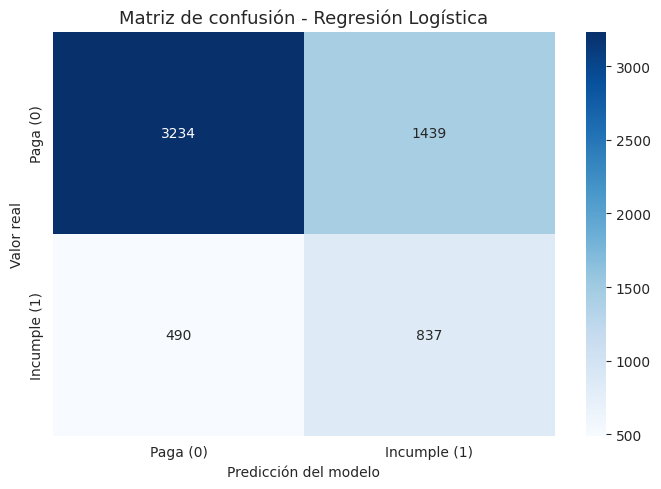

In [34]:
# Matriz de confusión del Modelo 1: Regresión Logística
cm_rl = confusion_matrix(y_test, y_pred_rl)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paga (0)', 'Incumple (1)'],
            yticklabels=['Paga (0)', 'Incumple (1)'])
plt.title('Matriz de confusión - Regresión Logística', fontsize=13)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### Qué nos muestra la matriz

La matriz nos deja ver con claridad cómo se reparten los aciertos y los errores
del modelo sobre los 6.000 clientes del conjunto de prueba.

En la diagonal están los aciertos: el modelo identificó correctamente a 3.234
clientes que pagan y a 837 clientes que incumplen.

Fuera de la diagonal están los dos tipos de error:

- 1.439 clientes que en realidad pagaban, pero el modelo marcó como incumplidores.
  Son las falsas alarmas, y explican por qué la precision de la clase "Incumple"
  daba baja.
- 490 clientes que incumplieron, pero el modelo dejó pasar como pagadores. Estos
  son los errores más costosos para un banco, porque significan crédito otorgado
  a alguien que probablemente no lo devuelva.

Lo que se ve acá conecta con lo que veníamos interpretando. Si miramos a los
incumplidores reales (1.327 en total), el modelo detectó a 837 y se le escaparon
490, lo que coincide con el recall de 0,63 que habíamos visto en el reporte. Y entre
los buenos pagadores se nota la cantidad de falsas alarmas: marcó como incumplidores
a 1.439 clientes que en realidad iban a pagar.

En resumen, el modelo logra pescar a buena parte de los incumplidores, que es lo
que más nos interesa, aunque lo hace a costa de generar varias falsas alarmas entre
los clientes que pagan bien.

### Evaluación del Modelo 2: Random Forest

Ahora le toca el turno al Random Forest. Vamos a medir su rendimiento sobre el
mismo conjunto de prueba y con las mismas métricas que usamos antes, para que la
comparación entre los dos modelos sea justa. Igual que con la Regresión Logística,
vamos a prestarle especial atención a cómo se comporta con la clase de incumplimiento.

In [35]:
# Evaluación del Modelo 2: Random Forest
print("=== RANDOM FOREST ===\n")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print()
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['Paga (0)', 'Incumple (1)']))

=== RANDOM FOREST ===

Accuracy: 0.811

Reporte de clasificación:
              precision    recall  f1-score   support

    Paga (0)       0.83      0.95      0.89      4673
Incumple (1)       0.64      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



### Qué nos dicen estos resultados

El Random Forest muestra un comportamiento bastante distinto al de la Regresión
Logística. Lo primero que salta a la vista es su accuracy de 0,81, bastante más
alto que el 0,68 del modelo anterior. Pero, como ya aprendimos, el accuracy por
sí solo no alcanza, así que hay que mirar la clase que nos importa.

Y ahí aparece lo interesante. El Random Forest tiene una precision de 0,64 para
la clase "Incumple", o sea que cuando marca a un cliente como incumplidor, acierta
bastante seguido y genera menos falsas alarmas. Pero su recall es de apenas 0,33,
lo que significa que solo detecta a un tercio de los clientes que realmente
incumplen. Los otros dos tercios se le escapan.

Es justo lo contrario de lo que vimos con la Regresión Logística, que detectaba
muchos más incumplidores (recall de 0,63) pero a costa de muchas falsas alarmas.
Acá el Random Forest es más "cauto": arriesga menos, así que se equivoca menos
cuando da la alarma, pero también deja pasar a muchos incumplidores.

Curiosamente, si miramos el F1-score de la clase "Incumple", los dos modelos
quedan casi empatados (0,44 el Random Forest y 0,46 la Regresión Logística). Esto
nos dice que, en el fondo, ninguno de los dos es claramente superior al otro:
simplemente equilibran de forma distinta el detectar incumplidores y el evitar
falsas alarmas.

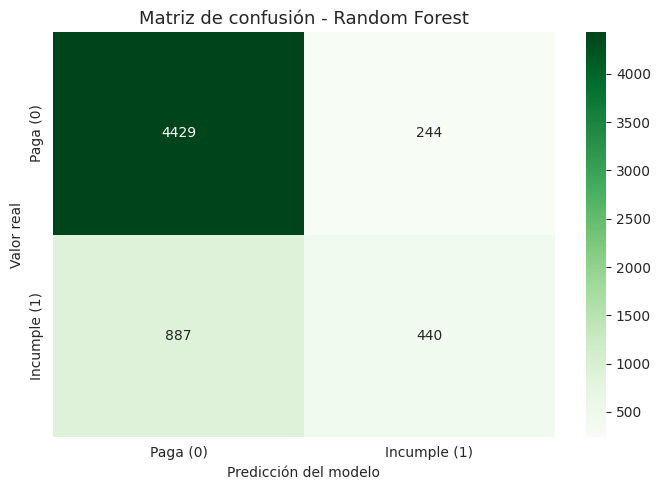

In [36]:
# Matriz de confusión del Modelo 2: Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Paga (0)', 'Incumple (1)'],
            yticklabels=['Paga (0)', 'Incumple (1)'])
plt.title('Matriz de confusión - Random Forest', fontsize=13)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### Qué nos muestra la matriz

La matriz del Random Forest deja ver con claridad ese comportamiento más "cauto"
del que hablábamos.

En la diagonal están los aciertos: el modelo identificó correctamente a 4.429
clientes que pagan y a 440 que incumplen.

Y fuera de la diagonal, los errores:

- 244 clientes que pagaban pero el modelo marcó como incumplidores. Son muy pocas
  falsas alarmas, mucho menos que las 1.439 de la Regresión Logística. Esto explica
  la buena precision que vimos en el reporte.
- 887 clientes que incumplieron pero el modelo dejó pasar como pagadores. Acá está
  el punto débil: de los 1.327 incumplidores reales, el modelo se "comió" a 887 y
  solo detectó a 440, lo que coincide con el recall bajo de 0,33.

Si comparamos esta matriz con la de la Regresión Logística, se ve clarísimo el
contraste. La Regresión Logística se equivocaba mucho marcando falsos incumplidores
(1.439), pero se le escapaban pocos incumplidores reales (490). El Random Forest
es al revés: casi no genera falsas alarmas (244), pero deja escapar muchísimos
incumplidores (887).

En otras palabras, el Random Forest prefiere "no arriesgar": solo marca como
incumplidor a un cliente cuando está bastante seguro. Eso lo hace muy confiable
cuando da la alarma, pero también hace que muchos incumplidores reales le pasen
desapercibidos.

### Comparación entre los dos modelos

Ya evaluamos los dos modelos por separado. Ahora los ponemos lado a lado para
verlos de un vistazo y poder decidir cuál se adapta mejor a nuestro problema.

Para que la comparación sea justa, los dos fueron entrenados y evaluados exactamente
con los mismos datos. Nos vamos a fijar sobre todo en las métricas de la clase
"Incumple", que es la que de verdad nos interesa predecir.

In [40]:
# Armar una tabla comparativa con las métricas de ambos modelos
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (Incumple)', 'Recall (Incumple)', 'F1-score (Incumple)'],
    'Regresión Logística': [
        accuracy_score(y_test, y_pred_rl),
        precision_score(y_test, y_pred_rl),
        recall_score(y_test, y_pred_rl),
        f1_score(y_test, y_pred_rl)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})

# Redondear a 3 decimales para que se vea prolijo
comparacion['Regresión Logística'] = comparacion['Regresión Logística'].round(3)
comparacion['Random Forest'] = comparacion['Random Forest'].round(3)

print("COMPARACIÓN DE MODELOS")
comparacion

COMPARACIÓN DE MODELOS


,Métrica,Regresión Logística,Random Forest
0,Accuracy,0.678,0.812
1,Precision (Incumple),0.368,0.643
2,Recall (Incumple),0.631,0.332
3,F1-score (Incumple),0.465,0.438


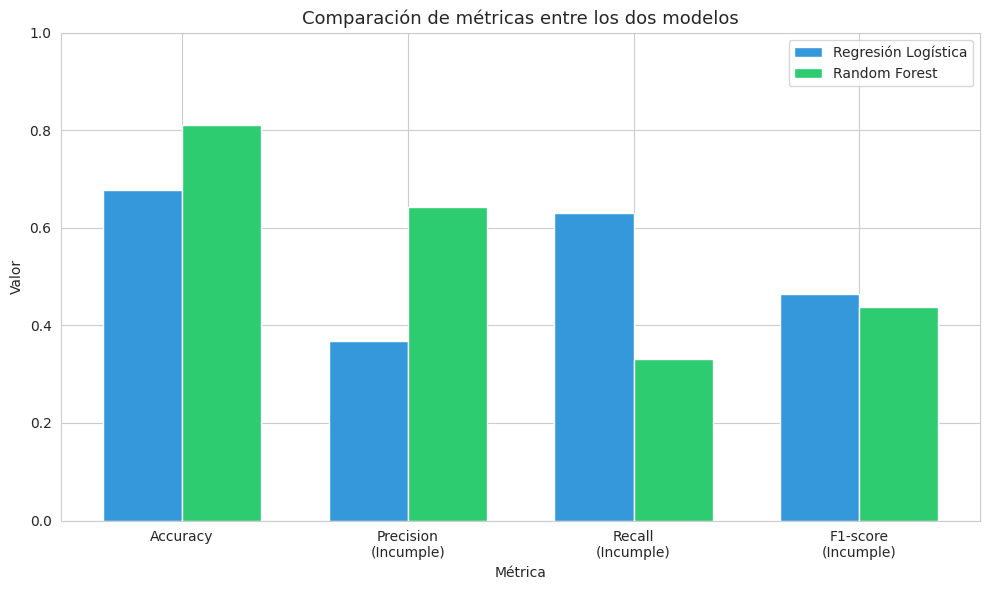

In [41]:
# Gráfico de barras comparando las métricas de ambos modelos
metricas = ['Accuracy', 'Precision\n(Incumple)', 'Recall\n(Incumple)', 'F1-score\n(Incumple)']
valores_rl = [accuracy_score(y_test, y_pred_rl), precision_score(y_test, y_pred_rl),
              recall_score(y_test, y_pred_rl), f1_score(y_test, y_pred_rl)]
valores_rf = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
              recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)]

x = np.arange(len(metricas))
ancho = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - ancho/2, valores_rl, ancho, label='Regresión Logística', color='#3498db')
plt.bar(x + ancho/2, valores_rf, ancho, label='Random Forest', color='#2ecc71')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.title('Comparación de métricas entre los dos modelos', fontsize=13)
plt.xticks(x, metricas)
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Qué modelo conviene

Mirando la tabla y el gráfico, se ve enseguida que ningún modelo le gana al otro
en todo. Cada uno tiene sus fortalezas.

El Random Forest gana claramente en accuracy (0,81 contra 0,68) y en precision
(0,64 contra 0,37). Es decir, acierta más en general y, cuando marca a alguien
como incumplidor, se equivoca menos.

La Regresión Logística, en cambio, gana en lo que para este problema es lo más
importante: el recall (0,63 contra 0,33). Detecta a casi el doble de incumplidores
reales que el Random Forest.

Y el F1-score, que es la métrica que equilibra precision y recall, queda
prácticamente empatado: 0,47 para la Regresión Logística y 0,44 para el Random
Forest. Esto confirma que, en el fondo, los dos modelos tienen un rendimiento
parecido, solo que lo reparten de manera distinta.

Entonces, ¿con cuál nos quedamos? Acá no hay una única respuesta correcta, depende
de qué busca el banco. Pero si pensamos en el objetivo del problema, que es
anticipar qué clientes van a incumplir, hay que tener en cuenta que dejar pasar a
un incumplidor es un error caro: significa darle crédito a alguien que probablemente
no lo devuelva. Equivocarse marcando a un buen cliente es un error mucho más leve.

Por eso, para este caso puntual, nos inclinamos por la Regresión Logística. Aunque
tenga menos accuracy y genere más falsas alarmas, detecta a muchos más incumplidores,
que es justamente lo que más le interesa cuidar a un banco. El Random Forest sería
una mejor opción si lo que se buscara fuera tener alarmas muy confiables sin molestar
a los buenos clientes.


### Qué variables fueron las más importantes

Una ventaja del Random Forest es que nos puede decir en qué variables se apoyó más
para hacer sus predicciones. Mientras va construyendo sus árboles, el modelo mide
qué tan útil le resulta cada variable para separar a los clientes que pagan de los
que incumplen, y con eso arma una especie de ranking de importancia.

Esto es interesante porque nos permite comparar lo que "aprendió" el modelo con lo
que ya habíamos visto en el análisis exploratorio.

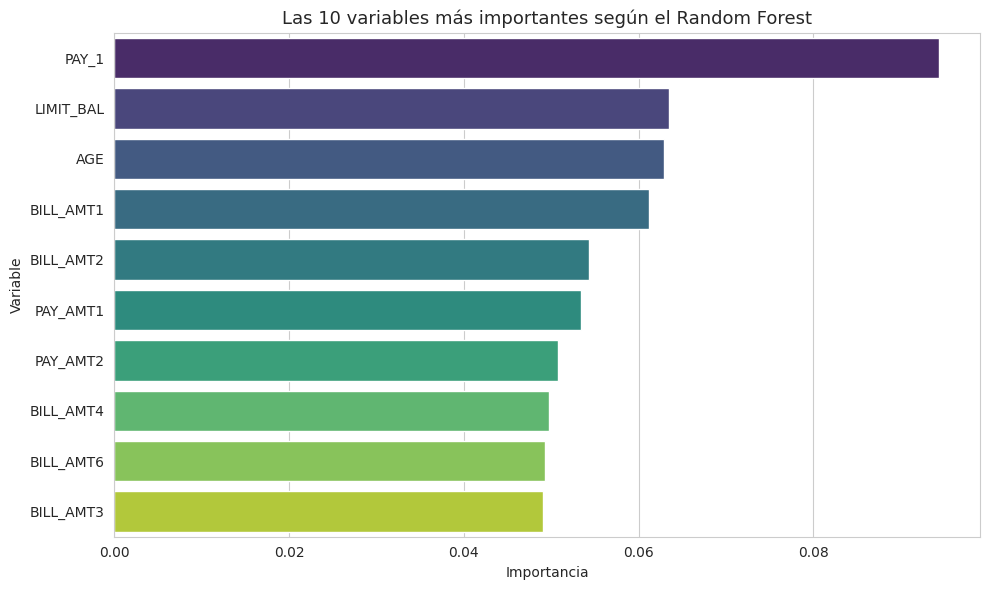

In [42]:
# Importancia de las variables según el Random Forest
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Graficar las 10 variables más importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias.head(10), x='Importancia', y='Variable',
            hue='Variable', palette='viridis', legend=False)
plt.title('Las 10 variables más importantes según el Random Forest', fontsize=13)
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Qué nos dice este gráfico

El gráfico deja algo muy claro: `PAY_1`, el estado de pago del mes más reciente,
es por lejos la variable más importante para el Random Forest, bastante por encima
de todas las demás. Esto confirma lo que ya habíamos visto en el análisis
exploratorio, cuando el mapa de calor nos mostró que `PAY_1` era la variable más
relacionada con el incumplimiento. Es lindo ver que el modelo, por su cuenta, llegó
a la misma conclusión: el comportamiento de pago reciente es el mejor indicador de
lo que va a pasar después.

Después de `PAY_1` aparecen `LIMIT_BAL` y un grupo de variables de montos bastante
parejas entre sí.

Hay un detalle que llama la atención: la edad (`AGE`) aparece bastante arriba en
este ranking, a pesar de que en el análisis exploratorio habíamos visto que casi
no servía para distinguir entre los que pagan y los que no. Esto no es una
contradicción, sino algo interesante. La correlación que vimos antes mide solo
relaciones directas y lineales, mientras que el Random Forest puede aprovechar una
variable combinándola con otras o de formas más complejas. Es decir, la edad por
sí sola no dice mucho, pero al modelo le sirve como variable de apoyo para afinar
sus decisiones junto al resto.

---

# CONCLUSIÓN FINAL

---

---

# Informe Final

## De qué se trató este trabajo

El objetivo de este trabajo fue construir un modelo capaz de predecir si un cliente
de tarjeta de crédito va a incumplir el pago del mes siguiente. Para eso usamos un
conjunto de datos con información de 30.000 clientes de tarjetas de crédito de
Taiwán, que incluía datos como la edad, el límite de crédito, el historial de pagos
de los últimos meses y los montos facturados y pagados.

La idea era, a partir de toda esa información, entrenar modelos de Machine Learning
que aprendieran a anticipar qué clientes representan un riesgo de no pagar.

## Qué encontramos al explorar los datos

Lo primero que hicimos fue explorar los datos en profundidad, y aparecieron varias
cosas interesantes.

La más importante fue que el conjunto de datos estaba desbalanceado: de cada 10
clientes, alrededor de 8 pagaban bien y solo 2 incumplían. Esto fue clave, porque
condicionó todo lo que vino después. Un dato desbalanceado puede engañar: un modelo
que dijera "todos pagan" acertaría el 78% de las veces sin servir absolutamente
para nada.

También vimos que la mayoría de los clientes eran adultos jóvenes, de entre 25 y
40 años, y que algunas variables tenían valores que no estaban bien documentados,
los cuales tuvimos que acomodar.

El hallazgo más útil fue descubrir cuáles variables servían para predecir. El
historial de pagos reciente, sobre todo el del último mes, resultó ser el mejor
indicador: si una persona se viene atrasando, lo más probable es que siga
incumpliendo. En cambio, otras variables como la edad casi no ayudaban a distinguir
entre un buen y un mal pagador.

## Qué hicimos para preparar los datos

Antes de entrenar los modelos, tuvimos que dejar los datos en condiciones. Acomodamos
los valores raros que habíamos detectado, transformamos las variables que eran
categorías para que los modelos las entendieran bien, y pusimos todas las variables
numéricas en una escala comparable.

También separamos los datos en dos partes: una para que los modelos aprendieran y
otra, que dejamos aparte, para ponerlos a prueba con casos que nunca habían visto.
Esto es importante para saber si el modelo realmente aprendió o si solo memorizó.

## Los modelos que entrenamos

Entrenamos dos modelos distintos para poder compararlos:

- La Regresión Logística, un modelo más simple, que estima la probabilidad de que
  un cliente incumpla.
- El Random Forest, un modelo más complejo, que combina la opinión de muchos
  "árboles de decisión" para llegar a un resultado.

A los dos les avisamos que el conjunto de datos estaba desbalanceado, para que no
ignoraran a los clientes que incumplen, que eran justamente los que más nos
interesaba detectar.

## Qué resultados obtuvimos

Acá apareció lo más interesante del trabajo. Los dos modelos terminaron teniendo
personalidades opuestas:

El Random Forest acertó más en general y, cuando marcaba a un cliente como
incumplidor, casi siempre tenía razón. Pero tenía un problema grande: se le escapaban
muchos incumplidores reales, detectaba solo a uno de cada tres.

La Regresión Logística acertaba menos en total y generaba más falsas alarmas, pero
a cambio detectaba a muchos más incumplidores, casi dos de cada tres.

Curiosamente, al medir el rendimiento con una métrica que equilibra las dos cosas,
los dos modelos quedaron casi empatados. Ninguno era claramente mejor que el otro,
simplemente resolvían el problema de maneras distintas.

## Cuál modelo elegimos y por qué

Después de comparar, nos inclinamos por la Regresión Logística para este problema
puntual.

El razonamiento es el siguiente: para un banco, dejar pasar a un cliente que va a
incumplir es un error caro, porque significa prestarle plata a alguien que no la
va a devolver. En cambio, marcar por error a un buen cliente es un error mucho más
leve. Como la Regresión Logística es la que mejor detecta a los incumplidores,
aunque no sea perfecta, es la opción más útil para el objetivo del problema.

## Conclusión

A lo largo del trabajo recorrimos todo el proceso de un análisis de datos:
exploramos la información, la limpiamos, la preparamos, entrenamos dos modelos y
los evaluamos.

La conclusión principal es que sí es posible anticipar, con una precisión razonable,
qué clientes tienen riesgo de incumplir, y que la información más valiosa para
hacerlo es el comportamiento de pago reciente del cliente.

También aprendimos algo importante sobre el análisis de datos en sí: que no alcanza
con mirar un solo número para decidir si un modelo es bueno. Un modelo con un
porcentaje de acierto alto puede ser inútil si no detecta lo que realmente importa.
Elegir el modelo correcto depende siempre de entender bien cuál es el objetivo del
problema que se quiere resolver.